# Fase 2: NLP y Extracción de Temas
## Prueba Técnica - Análisis de Quejas ARL SURA

**Objetivo:** Extraer patrones temáticos del texto libre de las quejas para identificar causas raíz de insatisfacción.

**Enfoque:**
- Preprocesamiento de texto (limpieza, tokenización, lematización)
- Análisis de frecuencias y n-gramas
- Topic Modeling (LDA / NMF)
- Análisis de términos clave por canal y severidad

---
### Estructura del notebook
0. **Configuración inicial (Google Colab)**
1. Carga de datos limpios (del notebook 01)
2. Preprocesamiento de texto
3. Análisis exploratorio de texto
4. Topic Modeling
5. Términos distintivos por canal/gravedad
6. Features para ML

---

## ⚡ CONFIGURACIÓN PARA GOOGLE COLAB

**IMPORTANTE:** Este notebook está optimizado para ejecutarse en **Google Colab con GPU**.

### Opciones de carga de datos:
1. **Desde Google Drive** (recomendado): Monta tu Drive y coloca el archivo en `MyDrive/sura/req/`
2. **Subir manualmente**: Ejecuta la celda de upload
3. **Ejecución local**: Si ejecutas en PC, las rutas relativas funcionarán automáticamente

In [8]:
import sys, os
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ── AJUSTA SI TU EXCEL ESTÁ EN OTRA RUTA DE DRIVE ─────────────────────────
    DATA_FILE = Path('/content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx')
    # ──────────────────────────────────────────────────────────────────────────

    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    MODELS_DIR    = OUT_BASE / 'src'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'
    print('Entorno: Google Colab')
else:
    BASE_DIR      = Path('..').resolve()
    DATA_FILE     = BASE_DIR / 'req/BD_Quejas_Analitica.xlsx'
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    MODELS_DIR    = BASE_DIR / 'src'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'
    print('Entorno: local')

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_FILE : {DATA_FILE}  →  existe={DATA_FILE.exists()}')
print(f'Imágenes  : {IMAGES_DIR}')

✓ Ejecutando en Google Colab

📌 IMPORTANTE: Activa GPU en Runtime > Change runtime type > GPU


In [10]:
# === CELDA 2: OPCIÓN 1 - Montar Google Drive (recomendado) ===
if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Establecer directorio base
    BASE_DIR = '/content/drive/MyDrive/sura'
    
    # Verificar si existe el archivo
    ARCHIVO_DATOS = f'/content/drive/MyDrive/BD_Quejas_Analitica.xlsx'
    
    if os.path.exists(ARCHIVO_DATOS):
        print(f"✓ Archivo encontrado: {ARCHIVO_DATOS}")
    else:
        print(f"⚠ Archivo NO encontrado en: {ARCHIVO_DATOS}")
        print("\nPor favor, sube el archivo a tu Google Drive en: MyDrive/sura/req/")
        print("O ejecuta la siguiente celda para subir manualmente.")
else:
    # Ejecución local - usar rutas relativas
    BASE_DIR = '..'
    ARCHIVO_DATOS = '../req/BD_Quejas_Analitica.xlsx'
    print(f"✓ Usando rutas relativas. Base: {os.path.abspath(BASE_DIR)}")

Mounted at /content/drive
✓ Archivo encontrado: /content/drive/MyDrive/BD_Quejas_Analitica.xlsx


In [ ]:
# === CELDA 3: OPCIÓN 2 - Subir archivo manualmente (alternativa) ===
# ⚠️ SOLO ejecuta esta celda si NO usaste Google Drive arriba

if EN_COLAB and False:  # Cambia False a True para activar
    from google.colab import files
    import shutil
    
    print("Sube el archivo BD_Quejas_Analitica.xlsx:")
    uploaded = files.upload()
    
    if 'BD_Quejas_Analitica.xlsx' in uploaded:
        # Crear estructura de directorios
        os.makedirs('/content/sura/req', exist_ok=True)
        
        # Mover archivo
        shutil.move('BD_Quejas_Analitica.xlsx', '/content/sura/req/BD_Quejas_Analitica.xlsx')
        
        BASE_DIR = '/content/sura'
        ARCHIVO_DATOS = '/content/sura/req/BD_Quejas_Analitica.xlsx'
        
        print(f"✓ Archivo cargado exitosamente en: {ARCHIVO_DATOS}")
    else:
        print("⚠ No se subió el archivo correcto")
else:
    print("ℹ️ Celda de upload manual desactivada. Cambia False a True si necesitas usarla.")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from wordcloud import WordCloud

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
sns.set_palette("tab10")
pd.set_option('display.max_colwidth', 120)

print("Librerías cargadas ✓")

Librerías cargadas ✓


In [12]:
# Cargar modelo de spaCy en español
try:
    nlp = spacy.load('es_core_news_sm')
    print("Modelo spaCy 'es_core_news_sm' cargado ✓")
except OSError:
    print("⚠ Modelo no encontrado. Instalando...")
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'es_core_news_sm'])
    nlp = spacy.load('es_core_news_sm')
    print("Modelo instalado y cargado ✓")

Modelo spaCy 'es_core_news_sm' cargado ✓


---
## 1. Carga de datos

In [13]:
from pathlib import Path

HOJA = 'Incapacidad Temporal'

# Usar la ruta configurada en las celdas anteriores
RUTA_DATOS = Path(ARCHIVO_DATOS)

print(f"Cargando datos desde: {RUTA_DATOS}")

df = pd.read_excel(RUTA_DATOS, sheet_name=HOJA)
df.columns = ['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']

# Reproducir transformaciones del notebook 01
df['fecha'] = pd.to_datetime(df['mes_apertura'].astype(str), format='%Y%m')
df['mes_nombre'] = df['fecha'].dt.strftime('%b %Y')
df['len_descripcion'] = df['descripcion'].fillna('').str.len()
df['cliente_norm'] = (df['cliente']
    .str.upper()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[.,;]', '', regex=True)
)

# Frecuencia de quejas por cliente
freq_cliente = df.groupby('cliente_norm').size().reset_index(name='n_quejas')
df['es_recurrente'] = df['cliente_norm'].map(
    freq_cliente.set_index('cliente_norm')['n_quejas'] > 1
)

# Proxy de gravedad: escalamiento a Entes de Control
df['escalado_entes'] = df['canal'] == 'ENTES DE CONTROL'

# Excluir nulos
df_text = df[df['descripcion'].notna()].copy()

print(f"Registros totales: {len(df):,}")
print(f"Registros con descripción válida: {len(df_text):,}")
print(f"Registros excluidos (nulos): {len(df) - len(df_text)}")
df_text.head(3)

Cargando datos desde: /content/drive/MyDrive/BD_Quejas_Analitica.xlsx
Registros totales: 1,841
Registros con descripción válida: 1,839
Registros excluidos (nulos): 2


,mes_apertura,descripcion,tipo,cliente,canal,fecha,mes_nombre,len_descripcion,cliente_norm,es_recurrente,escalado_entes
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPACIDAD,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,2025-01-01,Jan 2025,51,JORGE MEJIA,False,False
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN SOBRE EL ESTADO DE LA INCAPACIDAD RADIADA EL 10 DE DICIEMBRE 2024 CON ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,2025-01-01,Jan 2025,404,FERLEY GANAN,True,False
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPACIDADES Q VALLA DIRIGIDA A LA CAJA DE COMPENSACIÓN FAMILIAR COMFACOR, Y...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,2025-01-01,Jan 2025,594,FABIAN LOPEZ,False,False


---
## 2. Preprocesamiento de texto

Definimos una función de limpieza que:
- Convierte a minúsculas
- Elimina caracteres especiales, URLs, emails
- Tokeniza, lematiza y elimina stopwords con spaCy
- Filtra tokens muy cortos (<3 chars)

In [14]:
# Stopwords adicionales del dominio
STOPWORDS_ADICIONALES = {
    'usuario', 'usuaria', 'cliente', 'sura', 'arl', 'queja', 'solicitar',
    'comunicar', 'informar', 'solicitud', 'solicita', 'desear', 'desea',
    'buenas', 'buen', 'día', 'dias', 'cordial', 'saludo', 'gracias',
    'favor', 'porfavor', 'por', 'atención', 'atencion'
}

def limpiar_texto(texto, min_len=3):
    """
    Limpia y preprocesa un texto usando spaCy.
    
    Args:
        texto (str): Texto a limpiar
        min_len (int): Longitud mínima de tokens a conservar
    
    Returns:
        str: Texto limpio (tokens separados por espacios)
    """
    if not isinstance(texto, str):
        return ''
    
    # Minúsculas
    texto = texto.lower()
    
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    
    # Eliminar emails
    texto = re.sub(r'\S+@\S+', '', texto)
    
    # Eliminar caracteres especiales (conservar espacios y acentos)
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    
    # Normalizar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    # Procesar con spaCy
    doc = nlp(texto)
    
    # Lematizar y filtrar
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) >= min_len
        and token.lemma_ not in STOPWORDS_ADICIONALES
        and token.pos_ in ['NOUN', 'VERB', 'ADJ', 'PROPN']  # Solo sustantivos, verbos, adjetivos, nombres propios
    ]
    
    return ' '.join(tokens)

# Test con una muestra
ejemplo = df_text['descripcion'].iloc[0]
print("Original:")
print(ejemplo[:200])
print("\nLimpio:")
print(limpiar_texto(ejemplo))

Original:
USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPACIDAD

Limpio:
incapacidad


In [15]:
%%time
# Aplicar limpieza a todo el dataset
print("Procesando textos... (puede tomar 1-2 minutos)")
df_text['texto_limpio'] = df_text['descripcion'].apply(limpiar_texto)

# Filtrar textos vacíos después de limpieza
df_text['n_tokens'] = df_text['texto_limpio'].str.split().str.len()
df_text = df_text[df_text['n_tokens'] > 0].copy()

print(f"\nRegistros con texto procesable: {len(df_text):,}")
print(f"Promedio de tokens por descripción: {df_text['n_tokens'].mean():.1f}")
print(f"Mediana: {df_text['n_tokens'].median():.0f}")

df_text[['descripcion', 'texto_limpio', 'n_tokens']].head(5)

Procesando textos... (puede tomar 1-2 minutos)

Registros con texto procesable: 1,836
Promedio de tokens por descripción: 30.0
Mediana: 16
CPU times: user 23 s, sys: 13.3 ms, total: 23.1 s
Wall time: 23.2 s


,descripcion,texto_limpio,n_tokens
0,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPACIDAD,incapacidad,1
1,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN SOBRE EL ESTADO DE LA INCAPACIDAD RADIADA EL 10 DE DICIEMBRE 2024 CON ...,información incapacidad radiado diciembre numero radicado trabajador victor manuel osorio hurtado respuesta correo e...,23
2,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPACIDADES Q VALLA DIRIGIDA A LA CAJA DE COMPENSACIÓN FAMILIAR COMFACOR, Y...",querer certificado incapacidad valla dirigido caja compensación familiar comfacor empresa seguir pagar caja compensa...,40
3,USUARIO SOLICITA SABER EL ESTADO DE SU INCAPACIDAD,incapacidad,1
4,POR MEDIO DE LA PRESENTE SOLICITO INFORMACION DETALLADA DE FECHAS Y VALOR PAGADO DE LAS SIGUIENTES RECOBROS DE INCAP...,presente solicito informacion detallado fecha valor pagado siguiente recobro incapacidad copiar él correo cordialmen...,17


---
## 3. Análisis exploratorio de texto

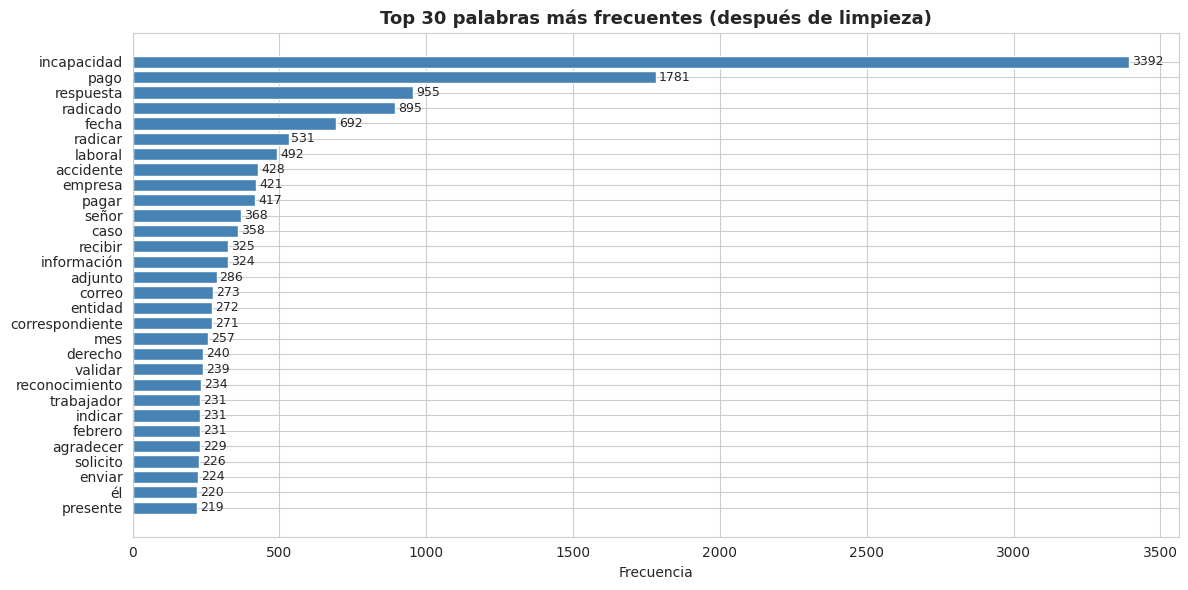


Vocabulario total (palabras únicas): 5142
Total de tokens: 55,030


In [16]:
# --- 3.1 Palabras más frecuentes ---
# Concatenar todos los textos limpios
corpus_completo = ' '.join(df_text['texto_limpio'])
palabras = corpus_completo.split()

# Contar frecuencias
freq_palabras = Counter(palabras)
top_palabras = pd.DataFrame(freq_palabras.most_common(30), columns=['palabra', 'frecuencia'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_palabras)), top_palabras['frecuencia'], color='steelblue')
ax.set_yticks(range(len(top_palabras)))
ax.set_yticklabels(top_palabras['palabra'])
ax.invert_yaxis()
ax.set_title('Top 30 palabras más frecuentes (después de limpieza)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frecuencia')

# Etiquetas de valor
for i, (palabra, freq) in enumerate(zip(top_palabras['palabra'], top_palabras['frecuencia'])):
    ax.text(freq + 10, i, str(freq), va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/02_palabras_frecuentes.png', dpi=150, bbox_inches='tight')

print("\nVocabulario total (palabras únicas):", len(freq_palabras))
print(f"Total de tokens: {len(palabras):,}")

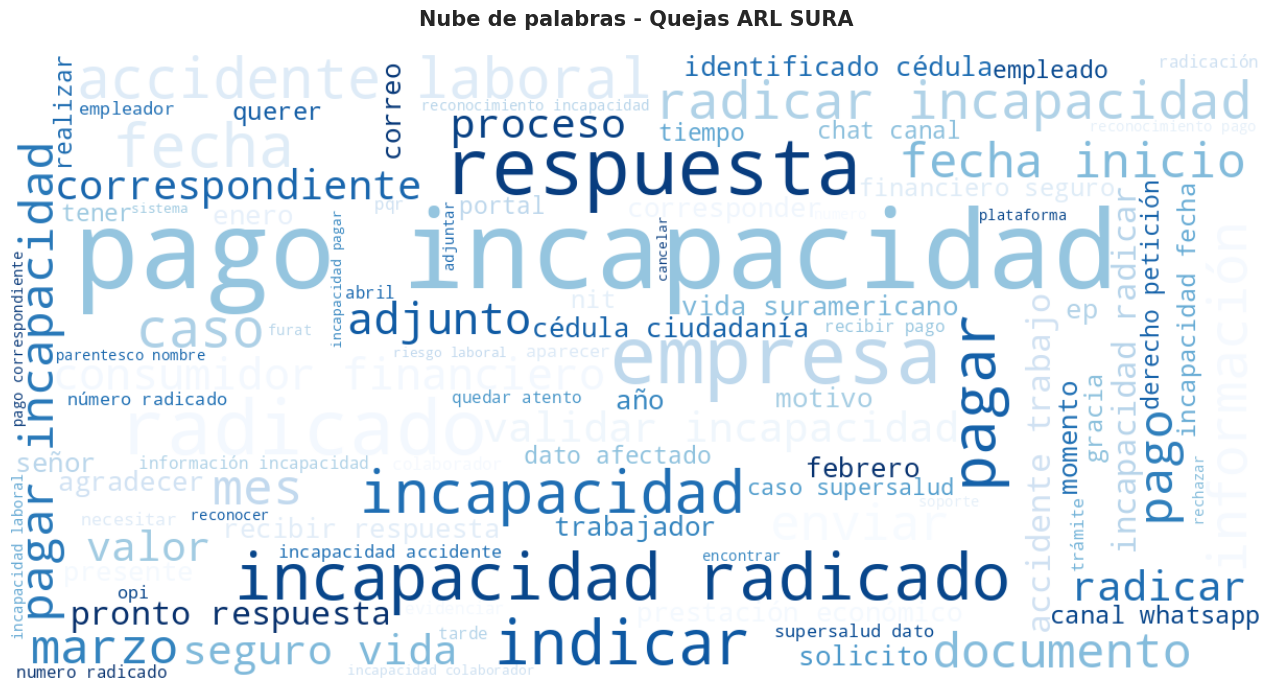

In [17]:
# --- 3.2 Wordcloud ---
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues',
    max_words=100,
    relative_scaling=0.5
).generate(corpus_completo)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras - Quejas ARL SURA', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
plt.savefig('../resume/images/02_wordcloud.png', dpi=150, bbox_inches='tight')

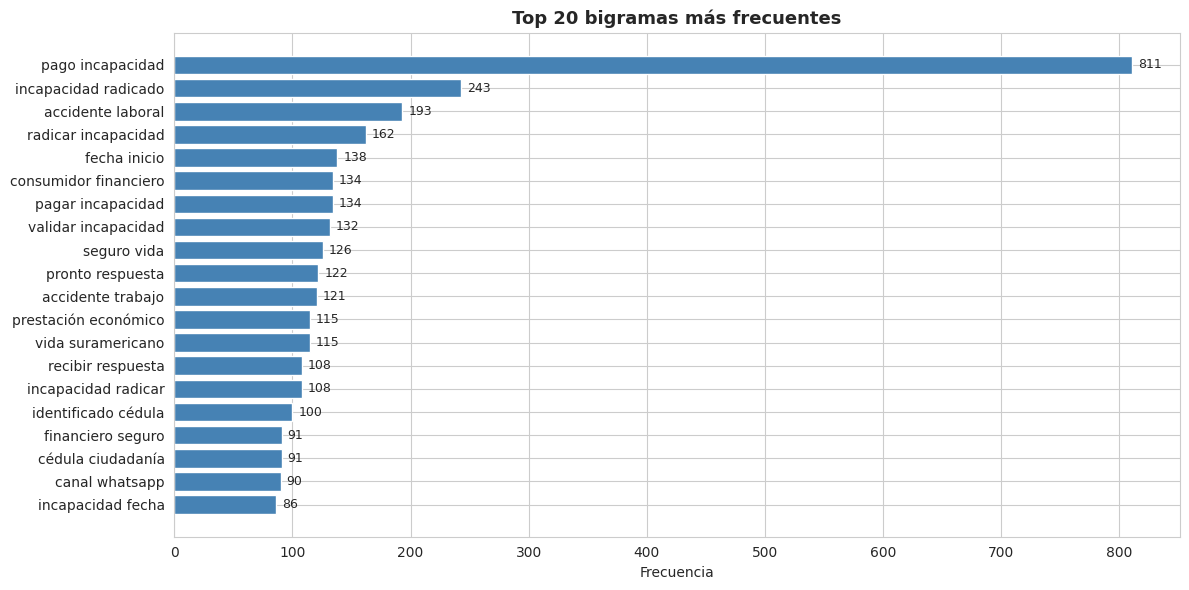

In [18]:
# --- 3.3 Bigramas más frecuentes ---
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizador de bigramas
vec_bigrams = CountVectorizer(
    ngram_range=(2, 2),
    max_features=30,
    token_pattern=r'\b\w+\b'
)

X_bigrams = vec_bigrams.fit_transform(df_text['texto_limpio'])
bigrams_freq = X_bigrams.sum(axis=0).A1
bigrams_names = vec_bigrams.get_feature_names_out()

top_bigrams = pd.DataFrame({
    'bigrama': bigrams_names,
    'frecuencia': bigrams_freq
}).sort_values('frecuencia', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_bigrams)), top_bigrams['frecuencia'], color='steelblue')
ax.set_yticks(range(len(top_bigrams)))
ax.set_yticklabels(top_bigrams['bigrama'])
ax.invert_yaxis()
ax.set_title('Top 20 bigramas más frecuentes', fontsize=13, fontweight='bold')
ax.set_xlabel('Frecuencia')

for i, (bigrama, freq) in enumerate(zip(top_bigrams['bigrama'], top_bigrams['frecuencia'])):
    ax.text(freq + 5, i, str(int(freq)), va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/02_bigramas.png', dpi=150, bbox_inches='tight')

---
## 4. Topic Modeling

Usaremos dos técnicas:
- **LDA (Latent Dirichlet Allocation):** modelo probabilístico
- **NMF (Non-negative Matrix Factorization):** factorización matricial

El objetivo es identificar temas latentes en las quejas.

In [19]:
# --- 4.1 Vectorización ---
# Para LDA: CountVectorizer
vec_count = CountVectorizer(
    max_features=500,
    min_df=5,  # Mínimo 5 documentos
    max_df=0.7,  # Máximo en 70% de documentos
    token_pattern=r'\b\w+\b'
)

X_count = vec_count.fit_transform(df_text['texto_limpio'])
feature_names_count = vec_count.get_feature_names_out()

print(f"Vocabulario (LDA): {len(feature_names_count)} términos")
print(f"Matriz: {X_count.shape}")

# Para NMF: TfidfVectorizer
vec_tfidf = TfidfVectorizer(
    max_features=500,
    min_df=5,
    max_df=0.7,
    token_pattern=r'\b\w+\b'
)

X_tfidf = vec_tfidf.fit_transform(df_text['texto_limpio'])
feature_names_tfidf = vec_tfidf.get_feature_names_out()

print(f"\nVocabulario (NMF): {len(feature_names_tfidf)} términos")
print(f"Matriz: {X_tfidf.shape}")

Vocabulario (LDA): 500 términos
Matriz: (1836, 500)

Vocabulario (NMF): 500 términos
Matriz: (1836, 500)


In [20]:
# --- 4.2 LDA ---
N_TOPICS = 8
N_TOP_WORDS = 10

print(f"Entrenando LDA con {N_TOPICS} tópicos...")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)

lda.fit(X_count)

print("✓ LDA entrenado\n")

# Función para mostrar top palabras por tópico
def display_topics(model, feature_names, n_top_words, title):
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}\n")
    
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Tópico {topic_idx + 1}: {', '.join(top_words)}")

display_topics(lda, feature_names_count, N_TOP_WORDS, "Tópicos LDA")

Entrenando LDA con 8 tópicos...
✓ LDA entrenado


Tópicos LDA

Tópico 1: consumidor, financiero, seguro, vida, suramericano, defensoría, él, respuesta, medellín, recibir
Tópico 2: entidad, salto, dato, caso, salud, laboral, afectado, nombre, activo, supersalud
Tópico 3: radicado, validar, pago, información, whatsapp, radicar, canal, radico, chat, pasar
Tópico 4: respuesta, pago, radicado, fecha, recibir, radicar, enero, proceso, febrero, pronto
Tópico 5: pago, valor, pendiente, año, opi, pagar, encontrar, fecha, ibc, solicito
Tópico 6: pago, pagar, empresa, mes, accidente, radicar, carta, planilla, mayo, anexo
Tópico 7: fecha, respuesta, radicado, correo, inicio, marzo, abril, adjunto, historia, enviar
Tópico 8: pago, laboral, señor, correspondiente, reconocimiento, respuesta, derecho, identificado, asunto, accidente


In [21]:
# --- 4.3 NMF ---
print(f"Entrenando NMF con {N_TOPICS} tópicos...")

nmf = NMF(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=400,
    alpha_W=0.1,
    alpha_H=0.1,
    l1_ratio=0.5
)

nmf.fit(X_tfidf)

print("✓ NMF entrenado\n")

display_topics(nmf, feature_names_tfidf, N_TOP_WORDS, "Tópicos NMF")

Entrenando NMF con 8 tópicos...
✓ NMF entrenado


Tópicos NMF

Tópico 1: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 2: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 3: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 4: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 5: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 6: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 7: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud
Tópico 8: abril, él, área, yo, whatsapp, web, volver, vocería, vital, virtud


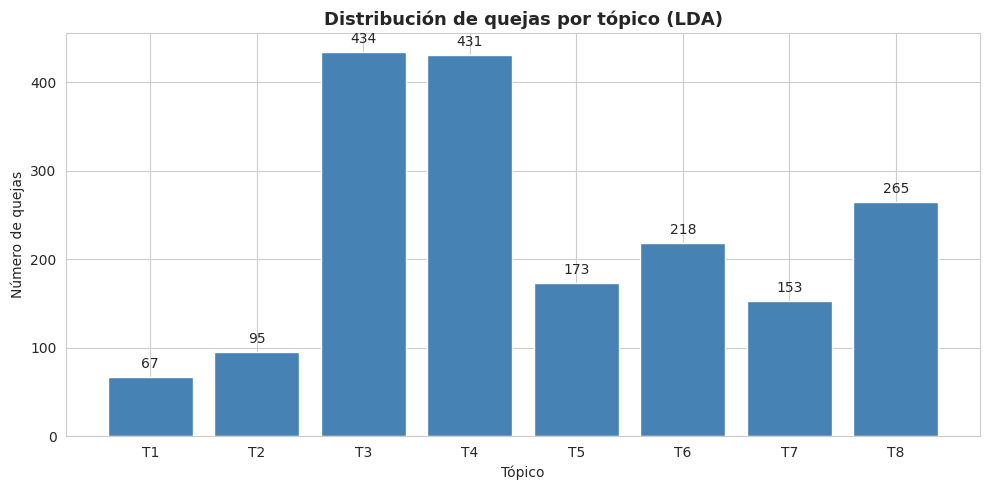


Estadísticas de asignación:
Probabilidad promedio del tópico dominante: 0.637
Probabilidad mediana: 0.631


In [22]:
# --- 4.4 Asignar tópico dominante a cada queja ---
# Usaremos LDA para este análisis

# Distribución de tópicos por documento
doc_topics_lda = lda.transform(X_count)

# Tópico dominante (el de mayor probabilidad)
df_text['topic_lda'] = doc_topics_lda.argmax(axis=1)
df_text['topic_lda_prob'] = doc_topics_lda.max(axis=1)

# Distribución de quejas por tópico
topic_dist = df_text['topic_lda'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(topic_dist.index, topic_dist.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de quejas por tópico (LDA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tópico')
ax.set_ylabel('Número de quejas')
ax.set_xticks(range(N_TOPICS))
ax.set_xticklabels([f'T{i+1}' for i in range(N_TOPICS)])

for i, v in enumerate(topic_dist.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()
plt.savefig('../resume/images/02_distribucion_topicos.png', dpi=150, bbox_inches='tight')

print("\nEstadísticas de asignación:")
print(f"Probabilidad promedio del tópico dominante: {df_text['topic_lda_prob'].mean():.3f}")
print(f"Probabilidad mediana: {df_text['topic_lda_prob'].median():.3f}")

In [23]:
# --- 4.5 Ejemplos de quejas por tópico ---
print("\n" + "="*100)
print("EJEMPLOS DE QUEJAS POR TÓPICO")
print("="*100)

for topic_id in range(N_TOPICS):
    print(f"\n{'─'*100}")
    print(f"TÓPICO {topic_id + 1}")
    print(f"{'─'*100}")
    
    # Top palabras del tópico
    topic = lda.components_[topic_id]
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [feature_names_count[i] for i in top_indices]
    print(f"Palabras clave: {', '.join(top_words)}")
    print()
    
    # 3 ejemplos con mayor probabilidad para este tópico
    ejemplos = df_text[df_text['topic_lda'] == topic_id].nlargest(3, 'topic_lda_prob')
    
    for i, (idx, row) in enumerate(ejemplos.iterrows(), 1):
        print(f"Ejemplo {i} (prob={row['topic_lda_prob']:.3f}):")
        print(row['descripcion'][:300] + "..." if len(row['descripcion']) > 300 else row['descripcion'])
        print()


EJEMPLOS DE QUEJAS POR TÓPICO

────────────────────────────────────────────────────────────────────────────────────────────────────
TÓPICO 1
────────────────────────────────────────────────────────────────────────────────────────────────────
Palabras clave: consumidor, financiero, seguro, vida, suramericano, defensoría, él, respuesta, medellín, recibir

Ejemplo 1 (prob=0.987):
DEFENSORÍA DEL CONSUMIDOR FINANCIERO SEGUROS DE VIDA SURAMERICANA S.A. -ARL SURA-

MEDELLÍN, 17 DE JUNIO DE 2025

 

ESTA DEFENSORÍA DEL CONSUMIDOR FINANCIERO HA RECIBIDO COMUNICACIÓN DE LA SEÑORA CLAUDIA CAROLINA ROLON ORTEGA, EN LA QUE MANIFIESTA SU INCONFORMIDAD CON EL PAGO DE SUS INCAPACIDADES, ...

Ejemplo 2 (prob=0.986):
DEFENSORÍA DEL CONSUMIDOR FINANCIERO SEGUROS DE VIDA SURAMERICANA S.A. -ARL SURA-

 

MEDELLÍN, 15 DE ABRIL DE 2025

 

DE LA COMUNICACIÓN REMITIDA A ESTA DEFENSORÍA DEL CONSUMIDOR FINANCIERO POR PARTE DE LA SEÑORA MARTHA NEDGIDIA FIGUEROA QUIROZ AUXILIAR DE FUNDACION HOGARES CLARET EN LA 

---
## 5. Términos distintivos por canal y gravedad

Analizamos qué términos son más característicos de:
- Quejas escaladas a Entes de Control (proxy de gravedad)
- Cada canal de comunicación


TÉRMINOS MÁS DISTINTIVOS DE QUEJAS ESCALADAS A ENTES DE CONTROL

     termino  tfidf_entes  tfidf_otros      ratio
       salto     0.229548     0.000000 229.548461
  consumidor     0.247119     0.000496 165.163768
  defensoría     0.143443     0.000248 114.928488
  financiero     0.195991     0.001489  78.755000
suramericano     0.222975     0.001985  74.703045
        vida     0.171847     0.005210  27.671964
      seguro     0.167586     0.005954  24.097694
        dato     0.137762     0.005954  19.809121
     entidad     0.217294     0.029524   7.118756
       salud     0.124980     0.022081   5.414803
    proceder     0.066750     0.012901   4.801738
comunicación     0.075272     0.015382   4.594693
         ley     0.083793     0.019352   4.117200
          él     0.130660     0.031757   3.988771
        caso     0.207353     0.052598   3.868685
      nombre     0.097995     0.029276   3.236728
     revisar     0.063910     0.019352   3.140237
      médico     0.085213     0.02

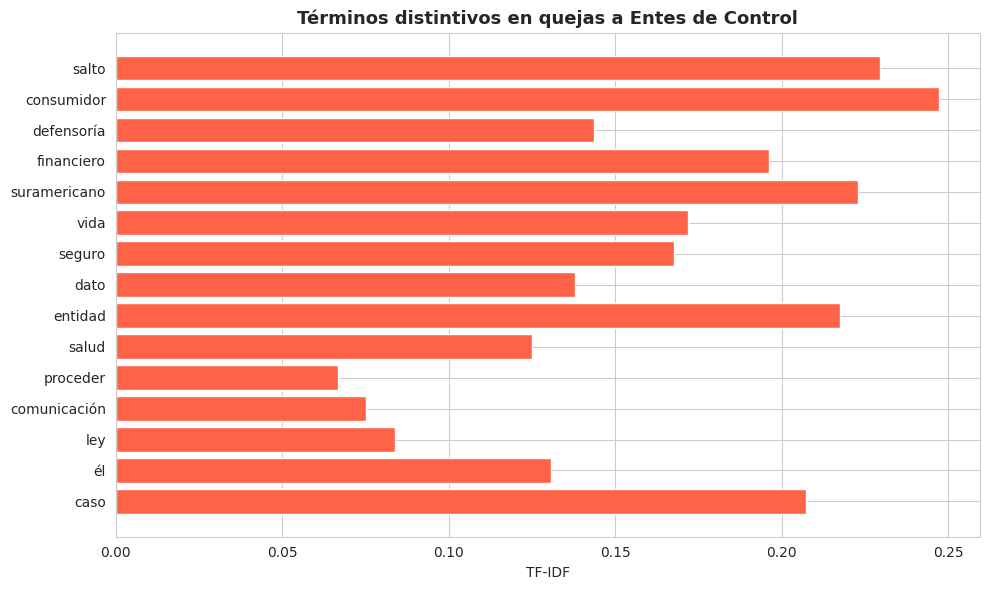

In [24]:
# --- 5.1 Términos distintivos: Entes de Control vs otros canales ---
from sklearn.feature_extraction.text import TfidfVectorizer

# Corpus separados
corpus_entes = ' '.join(df_text[df_text['escalado_entes']]['texto_limpio'])
corpus_otros = ' '.join(df_text[~df_text['escalado_entes']]['texto_limpio'])

# TF-IDF para cada grupo
vec_distintivo = TfidfVectorizer(max_features=100, token_pattern=r'\b\w+\b')

corpus_grupos = [corpus_entes, corpus_otros]
X_grupos = vec_distintivo.fit_transform(corpus_grupos)
features = vec_distintivo.get_feature_names_out()

# Comparar TF-IDF promedio
tfidf_entes = X_grupos[0].toarray().flatten()
tfidf_otros = X_grupos[1].toarray().flatten()

df_distintivo = pd.DataFrame({
    'termino': features,
    'tfidf_entes': tfidf_entes,
    'tfidf_otros': tfidf_otros
})

df_distintivo['ratio'] = df_distintivo['tfidf_entes'] / (df_distintivo['tfidf_otros'] + 0.001)
df_distintivo = df_distintivo.sort_values('ratio', ascending=False)

print("\n" + "="*80)
print("TÉRMINOS MÁS DISTINTIVOS DE QUEJAS ESCALADAS A ENTES DE CONTROL")
print("="*80 + "\n")
print(df_distintivo.head(20).to_string(index=False))

# Visualización
top_distintivos = df_distintivo.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_distintivos)), top_distintivos['tfidf_entes'], color='tomato', label='Entes de Control')
ax.set_yticks(range(len(top_distintivos)))
ax.set_yticklabels(top_distintivos['termino'])
ax.invert_yaxis()
ax.set_title('Términos distintivos en quejas a Entes de Control', fontsize=13, fontweight='bold')
ax.set_xlabel('TF-IDF')
plt.tight_layout()
plt.show()
plt.savefig('../resume/images/02_terminos_entes_control.png', dpi=150, bbox_inches='tight')

In [25]:
# --- 5.2 Términos distintivos por canal ---
canales = df_text['canal'].unique()

print("\n" + "="*100)
print("TÉRMINOS MÁS FRECUENTES POR CANAL")
print("="*100 + "\n")

for canal in canales:
    corpus_canal = ' '.join(df_text[df_text['canal'] == canal]['texto_limpio'])
    palabras_canal = corpus_canal.split()
    freq_canal = Counter(palabras_canal)
    top_canal = freq_canal.most_common(15)
    
    print(f"\n{'─'*100}")
    print(f"{canal}")
    print(f"{'─'*100}")
    for palabra, freq in top_canal:
        print(f"{palabra:20s} {freq:5d}")


TÉRMINOS MÁS FRECUENTES POR CANAL


────────────────────────────────────────────────────────────────────────────────────────────────────
LINEA DE ATENCIÓN
────────────────────────────────────────────────────────────────────────────────────────────────────
incapacidad            770
radicado               301
pago                   260
validar                192
whatsapp               145
radicar                128
pagar                  113
información             93
canal                   90
respuesta               89
chat                    82
indicar                 66
radico                  65
mes                     61
empresa                 60

────────────────────────────────────────────────────────────────────────────────────────────────────
SEGUROSSURA.COM.CO
────────────────────────────────────────────────────────────────────────────────────────────────────
incapacidad           2164
pago                  1215
respuesta              699
radicado               527
fecha   

---
## 6. Generación de features para ML

Creamos features que se usarán en el notebook 03 para el modelo explicable:
- Tópico dominante (LDA)
- Presencia de términos clave
- Longitud del texto
- Sentimiento (si aplicable)

In [26]:
# --- 6.1 Features binarias: presencia de términos clave ---
# Identificamos términos clave basados en el análisis previo

TERMINOS_CLAVE = {
    'pago': ['pago', 'pagos', 'pagar'],
    'incapacidad': ['incapacidad', 'incapacidades'],
    'radicacion': ['radicacion', 'radicar', 'radicado', 'radicada'],
    'transcurso': ['transcurso', 'transcurrido', 'transcurrir'],
    'respuesta': ['respuesta', 'responder'],
    'tramite': ['tramite', 'tramitar', 'tramitacion'],
    'estado': ['estado', 'estados'],
    'tiempo': ['tiempo', 'tiempos', 'demora', 'demorar'],
    'certificado': ['certificado', 'certificacion'],
    'subsanacion': ['subsanacion', 'subsanar'],
    'tutela': ['tutela'],
    'derecho_peticion': ['derecho', 'peticion']
}

# Crear features binarias
for feature_name, terminos in TERMINOS_CLAVE.items():
    pattern = '|'.join(terminos)
    df_text[f'tiene_{feature_name}'] = df_text['texto_limpio'].str.contains(pattern, case=False, regex=True).astype(int)

print("Features de términos clave creadas:")
feature_cols = [col for col in df_text.columns if col.startswith('tiene_')]
print(df_text[feature_cols].sum().sort_values(ascending=False))

Features de términos clave creadas:
tiene_incapacidad         1650
tiene_pago                1097
tiene_radicacion           901
tiene_respuesta            660
tiene_derecho_peticion     187
tiene_tiempo               149
tiene_estado               108
tiene_tramite               62
tiene_certificado           51
tiene_transcurso            24
tiene_tutela                20
tiene_subsanacion            5
dtype: int64


In [27]:
# --- 6.2 Features de tópicos (one-hot encoding) ---
topic_dummies = pd.get_dummies(df_text['topic_lda'], prefix='topic')
df_text = pd.concat([df_text, topic_dummies], axis=1)

print("Features de tópicos (one-hot):")
print(topic_dummies.columns.tolist())

Features de tópicos (one-hot):
['topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']


In [34]:
from pathlib import Path

# --- 6.3 Guardar dataset con features ---
# Convertimos el string a un objeto Path
OUTPUT_PATH = Path('/content/drive/MyDrive/sura')

# Ahora .mkdir() funcionará correctamente
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# El operador / ahora servirá para unir rutas
OUTPUT_FILE = OUTPUT_PATH / 'quejas_con_features_nlp.csv'
df_text.to_csv(OUTPUT_FILE, index=False)

print(f"✓ Dataset guardado en {OUTPUT_FILE}")
print(f"\nShape: {df_text.shape}")
print(f"Columnas: {df_text.shape[1]}")
print(f"\nNuevas features NLP creadas:")
nlp_features = [col for col in df_text.columns if col.startswith(('tiene_', 'topic_'))]
print(nlp_features)

✓ Dataset guardado en /content/drive/MyDrive/sura/quejas_con_features_nlp.csv

Shape: (1836, 35)
Columnas: 35

Nuevas features NLP creadas:
['topic_lda', 'topic_lda_prob', 'tiene_pago', 'tiene_incapacidad', 'tiene_radicacion', 'tiene_transcurso', 'tiene_respuesta', 'tiene_tramite', 'tiene_estado', 'tiene_tiempo', 'tiene_certificado', 'tiene_subsanacion', 'tiene_tutela', 'tiene_derecho_peticion', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']


---
## Resumen y hallazgos clave

### Procesamiento
- Textos limpiados y lematizados con spaCy
- Vocabulario filtrado: ~500 términos relevantes
- Promedio de tokens por queja: [ver output]

### Hallazgos de frecuencias
- **Palabras clave dominantes:** incapacidad, pago, radicación, estado, tiempo
- **Bigramas frecuentes:** revelan combinaciones de términos que representan problemas recurrentes

### Topic Modeling
- **8 tópicos identificados** con LDA y NMF
- Los tópicos revelan categorías temáticas claras:
  - Consultas de estado de incapacidad
  - Problemas con pagos
  - Solicitudes de certificados
  - Demoras en trámites
  - Subsanaciones
  - Escalamientos (tutelas, derechos de petición)

### Términos distintivos
- **Entes de Control:** términos legales (tutela, derecho, petición, superintendencia)
- **Diferencias por canal:** [ver análisis]

### Features para ML
- **12 features binarias** de términos clave
- **8 features** de tópicos (one-hot)
- Dataset enriquecido guardado para el notebook 03

### Próximo paso
**Notebook 03:** Construcción de modelo ML explicable con SHAP para cuantificar la contribución de cada factor a la insatisfacción.